#Business Problem
We are a marketing agency, our primary objective is to maximize the return on investment (ROI) for our clients' advertising campaigns. Having recently executed parallel campaigns on Facebook and Google Ads, we now need to determine which platform yields superior performance across key metrics — clicks, conversions, and cost-effectiveness — to optimize resource allocation and deliver maximum value for our clients.

#Research Question
Which advertising platform is better overall - drives higher performance in terms of clicks, conversions, and cost-effectiveness?

#Column Descriptions
- Date: The date corresponding to each row of campaign data, ranging from January 1st, 2019, to December 31st, 2019.
- Ad Views: The number of times the ad was viewed.
- Ad Clicks: The number of clicks received on the ad.
- Ad Conversions: The number of conversions resulting from the ad.
- Cost per Ad: The cost associated with running the Facebook ad campaign.
- Click-Through Rate (CTR): The ratio of clicks to views, indicating the effectiveness of the ad in generating clicks.
- Conversion Rate: The ratio of conversions to clicks, reflecting the effectiveness of the ad in driving desired actions.
- Cost per Click (CPC): The average cost incurred per click on the ad.


### **Importing libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("marketing_campaign.csv")

In [ ]:
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad (in $),Facebook Click-Through Rate (Clicks / View) (in %),Facebook Conversion Rate (Conversions / Clicks) (in %),Facebook Cost per Click (Ad Cost / Clicks) (in $),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad (in $),AdWords Click-Through Rate (Clicks / View) (in %),AdWords Conversion Rate (Conversions / Click) (in %),AdWords Cost per Click (Ad Cost / Clicks) (in $)
0,01-01-2019 00:00,FB_Jan19,2116,18,8,126,0.83,42.73,7.14,AW_Jan19,4984,59,5,194,1.18,8.40,3.30
1,01-02-2019 00:00,FB_Jan19,3106,36,12,104,1.15,34.04,2.91,AW_Jan19,4022,71,6,75,1.77,7.80,1.05
2,01-03-2019 00:00,FB_Jan19,3105,26,8,102,0.84,31.45,3.89,AW_Jan19,3863,44,4,141,1.13,9.59,3.23
3,01-04-2019 00:00,FB_Jan19,1107,27,9,71,2.45,34.76,2.62,AW_Jan19,3911,49,5,141,1.26,11.08,2.86
4,01-05-2019 00:00,FB_Jan19,1317,15,7,78,1.10,47.59,5.38,AW_Jan19,4070,55,7,133,1.36,12.22,2.40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Date                                                    365 non-null    object 
 1   Facebook Ad Campaign                                    365 non-null    object 
 2   Facebook Ad Views                                       365 non-null    int64  
 3   Facebook Ad Clicks                                      365 non-null    int64  
 4   Facebook Ad Conversions                                 365 non-null    int64  
 5   Cost per Facebook Ad (in $)                             365 non-null    int64  
 6   Facebook Click-Through Rate (Clicks / View) (in %)      365 non-null    float64
 7   Facebook Conversion Rate (Conversions / Clicks) (in %)  365 non-null    float64
 8   Facebook Cost per Click (Ad Cost / Click

need to change date from object to datetime

In [ ]:
df.describe()

,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad (in $),Facebook Click-Through Rate (Clicks / View) (in %),Facebook Conversion Rate (Conversions / Clicks) (in %),Facebook Cost per Click (Ad Cost / Clicks) (in $),AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad (in $),AdWords Click-Through Rate (Clicks / View) (in %),AdWords Conversion Rate (Conversions / Click) (in %),AdWords Cost per Click (Ad Cost / Clicks) (in $)
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.00000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2179.687671,44.049315,11.742466,87.780822,2.201288,27.153288,2.187808,4717.19726,60.383562,5.980822,134.975342,1.295781,10.184356,2.377863
std,618.074639,12.140559,2.924786,28.263014,0.933193,4.165921,1.040820,561.11406,14.368225,1.628106,32.338304,0.338782,2.887445,0.856929
min,1050.000000,15.000000,5.000000,34.000000,0.830000,21.480000,0.610000,3714.00000,31.000000,3.000000,73.000000,0.570000,6.130000,0.850000
25%,1656.000000,35.000000,10.000000,63.000000,1.490000,23.800000,1.410000,4247.00000,49.000000,5.000000,110.000000,1.030000,7.700000,1.760000
50%,2202.000000,43.000000,12.000000,88.000000,2.000000,26.770000,2.020000,4711.00000,60.000000,6.000000,135.000000,1.290000,9.930000,2.290000
75%,2717.000000,54.000000,13.000000,111.000000,2.670000,28.970000,2.760000,5190.00000,73.000000,7.000000,162.000000,1.520000,12.030000,2.810000
max,3320.000000,73.000000,19.000000,144.000000,5.370000,47.590000,7.140000,5760.00000,89.000000,9.000000,197.000000,2.250000,20.060000,5.650000


#C**ampaigns Comparison**

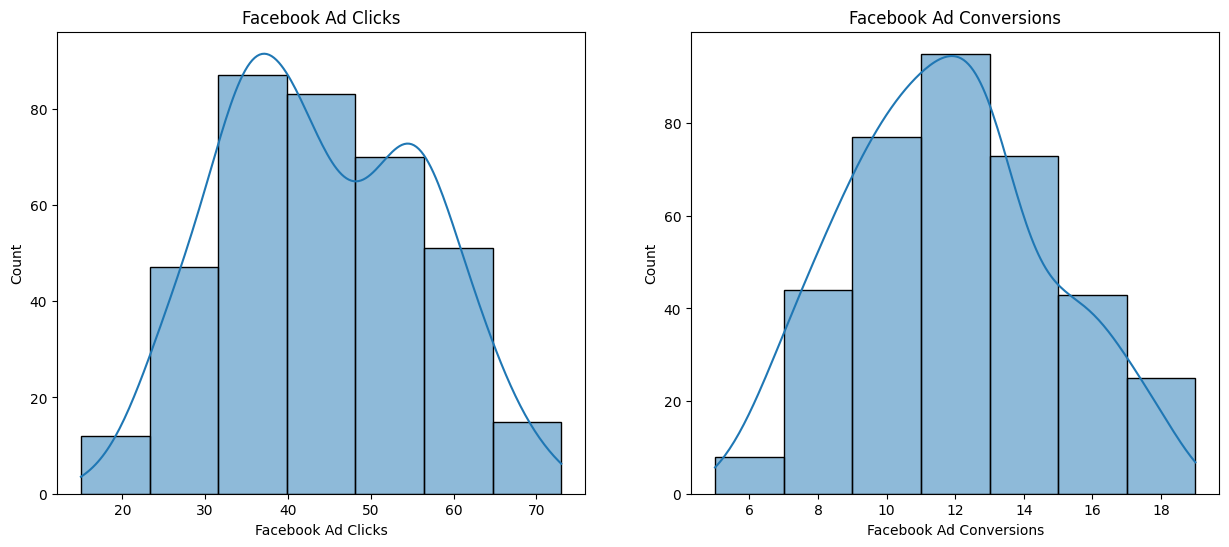

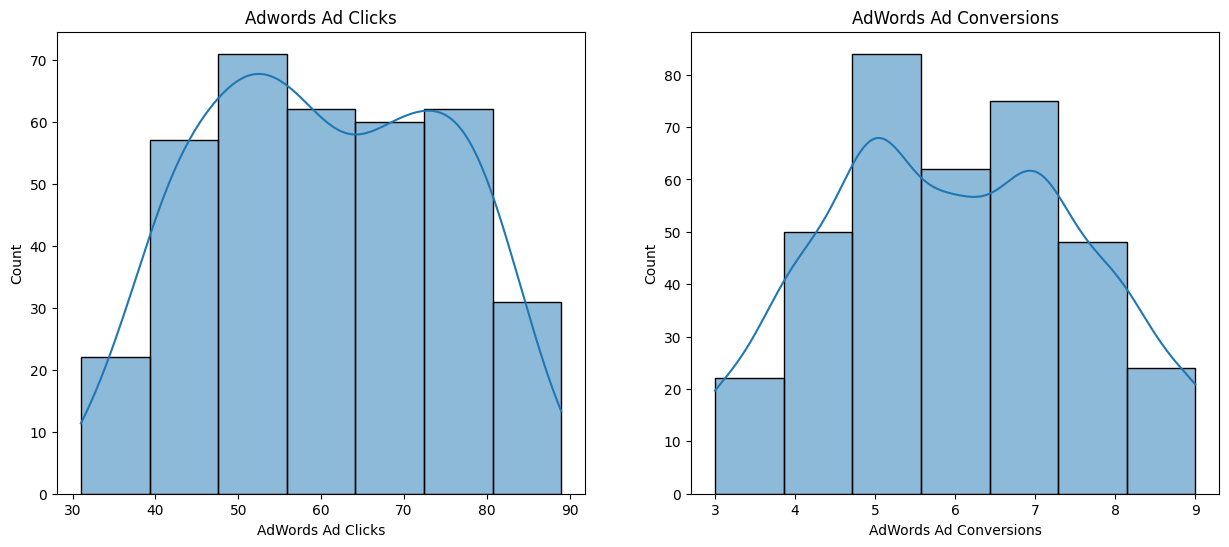

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['Facebook Ad Clicks'], bins = 7, edgecolor = 'k', kde = True)
plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['Facebook Ad Conversions'], bins = 7, edgecolor = 'k', kde = True)
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title("Adwords Ad Clicks")
sns.histplot(df['AdWords Ad Clicks'], bins = 7, edgecolor = 'k', kde = True)
plt.subplot(1,2,2)
plt.title("AdWords Ad Conversions")
sns.histplot(df['AdWords Ad Conversions'], bins = 7, edgecolor = 'k', kde = True)
plt.show()

* The symmetrical shape of the histogram suggests that the number of clicks and conversions is relatively evenly distributed. In other words, there are not many clicks or conversions that are outliers on either the high or low end.

* Facebook Campaign: Clicks primarily center around 35–45, while conversions consistently peak between 10 and 14.

* AdWords Campaign : Clicks show a slightly broader plateau centering around 50–55, whereas conversions peak prominently near 5 and 7.

#**High & Low Conversion Days per Campaigns**

### **Facebook Ad**

In [ ]:
df['Facebook Ad Conversions'].value_counts().head(10)

,count
Facebook Ad Conversions,
13,50
12,49
11,46
10,42
9,35
8,26
14,23
16,22
15,21


### **Adword Ad**

In [ ]:
df['AdWords Ad Conversions'].value_counts().head(10)

,count
AdWords Ad Conversions,
5,84
7,75
6,62
4,50
8,48
9,24
3,22


### **Creating a Conversion Category Column** for categorizing conversions
This is done to make tracking ad conversions easier for both campaigns

In [ ]:
def create_conversion_category(Conversion_col):
  category = []
  for conversion in df[Conversion_col]:
    if conversion < 6:
      category.append('Less than 6')
    elif 6 <= conversion < 11:
      category.append('6 - 10')
    elif 11 <= conversion < 16:
      category.append('11 - 15')
    else:
      category.append('more than 15')
  return category

df['Facebook Conversion Category'] = create_conversion_category('Facebook Ad Conversions')
df['AdWords Conversion Category'] = create_conversion_category('AdWords Ad Conversions')

In [ ]:
df[['Facebook Ad Conversions','Facebook Conversion Category','AdWords Ad Conversions','AdWords Conversion Category']].head(5)

,Facebook Ad Conversions,Facebook Conversion Category,AdWords Ad Conversions,AdWords Conversion Category
0,8,6 - 10,5,Less than 6
1,12,11 - 15,6,6 - 10
2,8,6 - 10,4,Less than 6
3,9,6 - 10,5,Less than 6
4,7,6 - 10,7,6 - 10


In [ ]:
df['Facebook Conversion Category'].value_counts()

,count
Facebook Conversion Category,
11 - 15,189
6 - 10,128
more than 15,47
Less than 6,1


In [ ]:
facebook = pd.DataFrame(df['Facebook Conversion Category'].value_counts()).reset_index().rename(columns = {'Facebook Conversion Category':'Category'})
print(facebook)

       Category  count
0       11 - 15    189
1        6 - 10    128
2  more than 15     47
3   Less than 6      1


In [ ]:
df['AdWords Conversion Category'].value_counts().reset_index()

,AdWords Conversion Category,count
0,6 - 10,209
1,Less than 6,156


In [ ]:
adwords = pd.DataFrame(df['AdWords Conversion Category'].value_counts()).reset_index().rename(columns = {'AdWords Conversion Category':'Category'})
print(adwords)

      Category  count
0       6 - 10    209
1  Less than 6    156


In [ ]:
merge_df = pd.merge(facebook, adwords, on = 'Category', how = 'left').fillna(0).reset_index().rename(columns = {'count_x':'Facebook Conversion Day Count','count_y':'AdWords Conversion Day Count'})
merge_df

,index,Category,Facebook Conversion Day Count,AdWords Conversion Day Count
0,0,11 - 15,189,0.0
1,1,6 - 10,128,209.0
2,2,more than 15,47,0.0
3,3,Less than 6,1,156.0


In [ ]:
c_arrange = merge_df.iloc[[3,1,0,2]]
c_arrange

,index,Category,Facebook Conversion Day Count,AdWords Conversion Day Count
3,3,Less than 6,1,156.0
1,1,6 - 10,128,209.0
0,0,11 - 15,189,0.0
2,2,more than 15,47,0.0


In [ ]:
x = np.arange(len(c_arrange))
x

array([0, 1, 2, 3])

# **Campaign Conversions per Conversion Category by Number of Days**

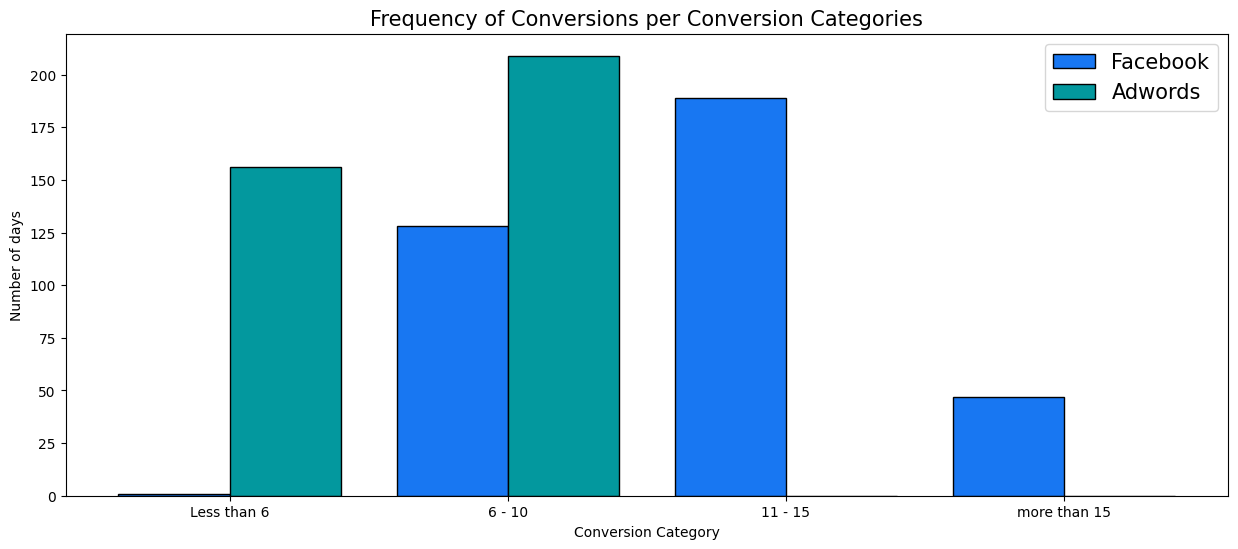

In [ ]:
x = np.arange(len(c_arrange))
plt.figure(figsize = (15,6))

plt.bar(x - 0.2, c_arrange['Facebook Conversion Day Count'], 0.4, label = 'Facebook', color = '#1877F2', linewidth = 1, edgecolor = 'k')
plt.bar(x + 0.2, c_arrange['AdWords Conversion Day Count'], 0.4, label = 'Adwords', color = '#03989E', linewidth = 1, edgecolor = 'k')

plt.xticks(x, c_arrange['Category'])
plt.xlabel("Conversion Category")
plt.ylabel("Number of days")
plt.title("Frequency of Conversions per Conversion Categories", fontsize = 15)
plt.legend(fontsize = 15)
plt.show()

In [ ]:
df['Facebook Ad Conversions'].sum()

np.int64(4286)

In [ ]:
df['AdWords Ad Conversions'].sum()

np.int64(2183)

Facebook is clearly getting more conversions throughout the year compared to adwords which is consistent around 6-10 conversions

#**Clicks vs Conversions**

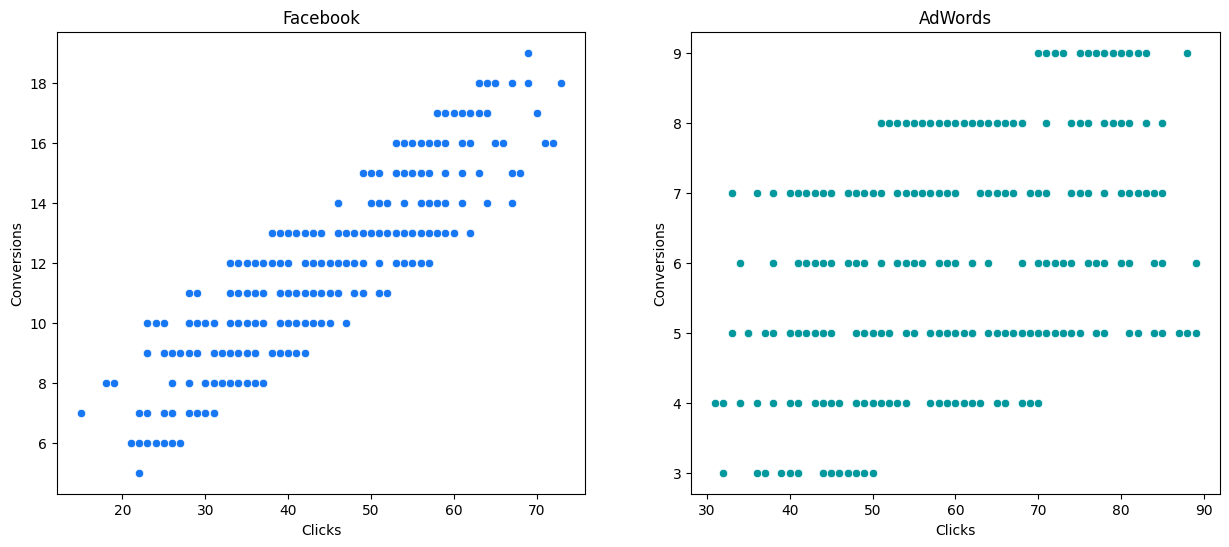

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(x = df['Facebook Ad Clicks'],y = df['Facebook Ad Conversions'], color = '#1877F2')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.subplot(1,2,2)
plt.title('AdWords')
sns.scatterplot(x = df['AdWords Ad Clicks'],y = df['AdWords Ad Conversions'], color = '#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.show()

* Facebook: Shows a strong, positive linear correlation. There is a clear, predictable trend where a higher volume of clicks directly translates to an increased number of conversions.

* AdWords: Unlike Facebook, increasing click volume on AdWords does not show a strong linear relationship with conversion growth, as a wide range of click counts result in identical conversion totals.

In [ ]:
Facebook_corr = df[['Facebook Ad Conversions','Facebook Ad Clicks']].corr()
Facebook_corr

,Facebook Ad Conversions,Facebook Ad Clicks
Facebook Ad Conversions,1.000000,0.873775
Facebook Ad Clicks,0.873775,1.000000


In [ ]:
AdWords_corr = df[['AdWords Ad Conversions','AdWords Ad Clicks']].corr()
AdWords_corr

,AdWords Ad Conversions,AdWords Ad Clicks
AdWords Ad Conversions,1.000000,0.447993
AdWords Ad Clicks,0.447993,1.000000


In [ ]:
print('Correlation Coeff \n--------------')
print('Facebook clicks (per conversions):',round(Facebook_corr.values[0,1],2))
print('AdWords clicks (per conversions) :',round(AdWords_corr.values[0,1],2))

Correlation Coeff 
--------------
Facebook clicks (per conversions): 0.87
AdWords clicks (per conversions) : 0.45


#**Hypothesis Testing**

**Hypothesis:** Advertising on Facebook will result in a greater number of conversions compared to advertising on AdWords.

**Null Hypothesis (H0):** There is no difference in the number of conversions between Facebook and AdWords, or the number of conversions from AdWords is greater than or equal to those from Facebook.

H0: µ_Facebook ≤ µ_AdWords

**Alternate Hypothesis (H1):** The number of conversions from Facebook is greater than the number of conversions from AdWords.

H1: µ_Facebook > µ_AdWords

In [ ]:
df['Facebook Ad Conversions'].mean()

np.float64(11.742465753424657)

In [ ]:
df['AdWords Ad Conversions'].mean()

np.float64(5.980821917808219)

In [ ]:
print('Mean Conversion \n--------------')
print('Facebook :', round(df['Facebook Ad Conversions'].mean(),2))
print('AdWords :', round(df['AdWords Ad Conversions'].mean(),2))

Mean Conversion 
--------------
Facebook : 11.74
AdWords : 5.98


In [ ]:
t_stats, p_value = st.ttest_ind(a = df['Facebook Ad Conversions'], b = df['AdWords Ad Conversions'], equal_var = False)
print('\nT statistic', t_stats, '\np-value',p_value)
# comparing the p value with the significance of 5% or 0.05
if p_value < 0.05:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")


T statistic 32.88402060758184 
p-value 9.348918164530465e-134

p-value is less than significance value, Reject the null hypothesis


**T-Statistics**
* T-Statistic: Signal-to-Noise Ratio ($\frac{\text{Difference between Means}}{\text{Data Fluctuations}}$).
* Meaning: The performance gap between Facebook and AdWords is 32.88 times larger than the daily noise in the data.
* Takeaway: Anything $>2$ is significant. 32.88 means a massive, definitive separation.

**P-Value**
* P-Value: $9.34 \times 10^{-134}$
* What it is: The probability that this result is a random fluke. The chance of this gap happening by pure luck is effectively 0% ($133$ zeros after the decimal).
* Takeaway: Far below the $\alpha = 0.05$ threshold. Random chance is completely ruled out.

***Verdict: Reject $H_0$. Facebook's superiority is mathematically absolute.***

# ***We Can say Facebook is way better as a Platform compared to Adwords so lets proceed with Facebook for further detailed analysis***

##**Regression Analysis**

In [ ]:
# independent variable
X = df[['Facebook Ad Clicks']]

# dependent variable
y = df[['Facebook Ad Conversions']]

# initializing and fitting Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X,y)
prediction = reg_model.predict(X)

# model evaluation
r2 = r2_score(y, prediction)*100
mse = mean_squared_error(y, prediction)
print('Accuracy (R2 Score):',round(r2,2),'%')
print('Mean Squared Error:', round(mse,2))

Accuracy (R2 Score): 76.35 %
Mean Squared Error: 2.02


* **Accuracy ($R^2$ Score):** 76.35%This means
approximately 76.35% of the variance in Facebook Ad Conversions can be explained by the number of Facebook Ad Clicks. *It indicates a strong linear relationship.*
* **Mean Squared Error (MSE):** 2.02
On average, the squared difference between the actual conversions and the predicted conversions is 2.02. *Lower values indicate better fit.*

In [ ]:
print('Slope (m):', reg_model.coef_[0])
print('Intercept (b):', reg_model.intercept_)

Slope (m): [0.21050143]
Intercept (b): [2.47002215]


* **Slope ($m$):** For every 1 additional click received, conversions are expected to increase by roughly 0.21.
* **Intercept ($b$):** If there are 0 clicks, the model predicts a baseline of approximately 2.47 conversions (though practically, this serves as the starting point of the line, which can be understood if we draw the plot).

###**Plotting the Regression Plot**

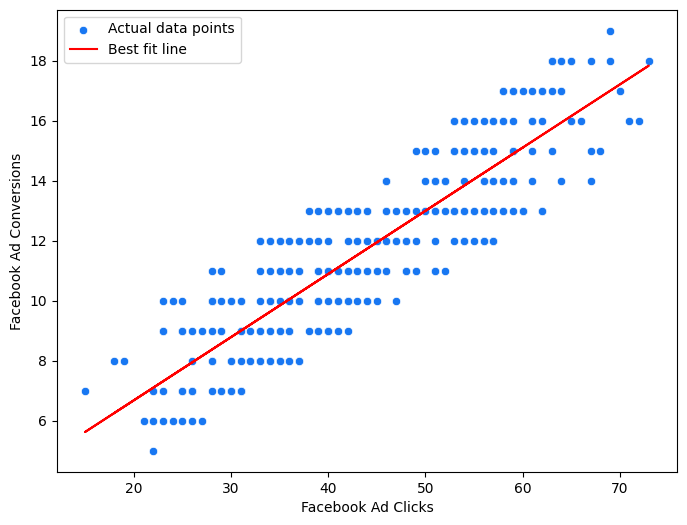

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x = df['Facebook Ad Clicks'],y = df['Facebook Ad Conversions'], color = '#1877F2', label = 'Actual data points')
plt.plot(df['Facebook Ad Clicks'], prediction, color = 'red', label = 'Best fit line')
plt.legend()
plt.show()

* Linear Trend: The red best-fit line confirms a strong, positive linear relationship between Facebook Ad Clicks and Conversions.

* Model Fit: The actual data points closely hug the regression line, indicating high predictability and a stable conversion rate.

* Predictive Value: The model establishes clear baseline expectations, predicting 13.0 conversions for 50 clicks and scaling up to 19.31 conversions for 80 clicks.

In [ ]:
print(f'For {50} Clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0],2)}')
print(f'For {80} Clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0],2)}')

For 50 Clicks, Expected Conversion : 13.0
For 80 Clicks, Expected Conversion : 19.31


#**Analysing Facebook Campaign Metrics Over Time**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 19 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Date                                                    365 non-null    object 
 1   Facebook Ad Campaign                                    365 non-null    object 
 2   Facebook Ad Views                                       365 non-null    int64  
 3   Facebook Ad Clicks                                      365 non-null    int64  
 4   Facebook Ad Conversions                                 365 non-null    int64  
 5   Cost per Facebook Ad (in $)                             365 non-null    int64  
 6   Facebook Click-Through Rate (Clicks / View) (in %)      365 non-null    float64
 7   Facebook Conversion Rate (Conversions / Clicks) (in %)  365 non-null    float64
 8   Facebook Cost per Click (Ad Cost / Click

In [ ]:
df.columns = df.columns.str.strip()

df = df[['Date', 'Facebook Ad Views',
         'Facebook Ad Clicks', 'Facebook Ad Conversions', 'Cost per Facebook Ad (in $)',
         'Facebook Click-Through Rate (Clicks / View) (in %)',
         'Facebook Conversion Rate (Conversions / Clicks) (in %)',
         'Facebook Cost per Click (Ad Cost / Clicks) (in $)']]

df.head()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad (in $),Facebook Click-Through Rate (Clicks / View) (in %),Facebook Conversion Rate (Conversions / Clicks) (in %),Facebook Cost per Click (Ad Cost / Clicks) (in $)
0,01-01-2019 00:00,2116,18,8,126,0.83,42.73,7.14
1,01-02-2019 00:00,3106,36,12,104,1.15,34.04,2.91
2,01-03-2019 00:00,3105,26,8,102,0.84,31.45,3.89
3,01-04-2019 00:00,1107,27,9,71,2.45,34.76,2.62
4,01-05-2019 00:00,1317,15,7,78,1.10,47.59,5.38


# **Facebook Ad Conversions by Months & Days of Week**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['month_idx'] = df['Date'].dt.month
df['week'] = df['Date'].dt.weekday

In [ ]:
df.head()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad (in $),Facebook Click-Through Rate (Clicks / View) (in %),Facebook Conversion Rate (Conversions / Clicks) (in %),Facebook Cost per Click (Ad Cost / Clicks) (in $),month_idx,week
0,2019-01-01,2116,18,8,126,0.83,42.73,7.14,1,1
1,2019-02-01,3106,36,12,104,1.15,34.04,2.91,2,4
2,2019-03-01,3105,26,8,102,0.84,31.45,3.89,3,4
3,2019-04-01,1107,27,9,71,2.45,34.76,2.62,4,0
4,2019-05-01,1317,15,7,78,1.10,47.59,5.38,5,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Date                                                    365 non-null    datetime64[ns]
 1   Facebook Ad Views                                       365 non-null    int64         
 2   Facebook Ad Clicks                                      365 non-null    int64         
 3   Facebook Ad Conversions                                 365 non-null    int64         
 4   Cost per Facebook Ad (in $)                             365 non-null    int64         
 5   Facebook Click-Through Rate (Clicks / View) (in %)      365 non-null    float64       
 6   Facebook Conversion Rate (Conversions / Clicks) (in %)  365 non-null    float64       
 7   Facebook Cost per Click (Ad Cost / Clicks) (in $)       365 no

In [ ]:
week = df.groupby('week')['Facebook Ad Conversions'].sum()
week_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat','Sun']
week.index = week_names
print(week)

Mon    624
Tue    661
Wed    603
Thu    582
Fri    602
Sat    602
Sun    612
Name: Facebook Ad Conversions, dtype: int64


## **Weekly Facebook Conversions**

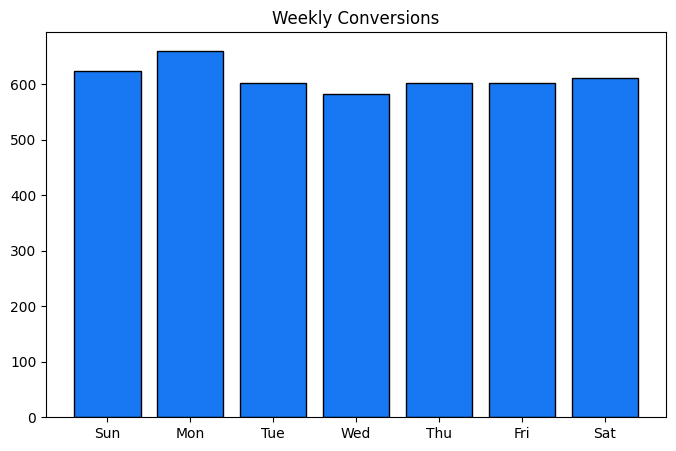

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Weekly Conversions')
weekly_conversions = df.groupby('week')['Facebook Ad Conversions'].sum()
week_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri','Sat']
plt.bar(week_names, weekly_conversions, color = '#1877F2', edgecolor='k')
plt.show()

- Weekly Distribution: Conversions are highly stable across the week, consistently hovering around the ~600 mark for almost every day.

- Peak Performance: Monday serves as the strongest day of the week, hitting the maximum volume at approximately 660 conversions.

- Weekly Low: Wednesday reflects the lowest performance drop, though it remains resilient at around 580 conversions.

In [ ]:
monthly = df.groupby('month_idx')['Facebook Ad Conversions'].sum()
month_names = ['Jan','Feb','Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec']
monthly.index = month_names
print(monthly)

Jan     346
Feb     302
Mar     341
Apr     361
May     338
June    329
July    383
Aug     355
Sep     354
Oct     405
Nov     373
Dec     399
Name: Facebook Ad Conversions, dtype: int64


## **Montly Facebook Ad Conversions**

In [ ]:
print("Unique values in your month column:", df['month_idx'].unique())
print("Total rows after cleaning:", len(df))

Unique values in your month column: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Total rows after cleaning: 365


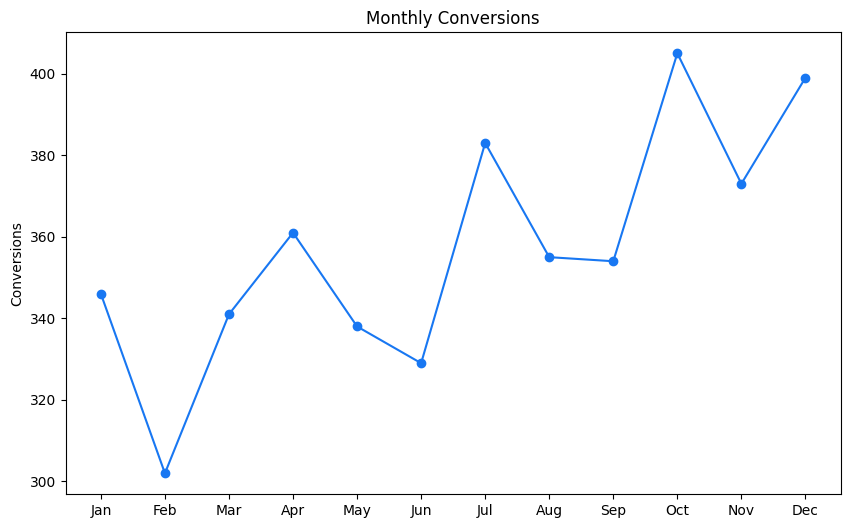

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Monthly Conversions')

month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly_conversions = df.groupby('month_idx')[['Facebook Ad Conversions']].sum().reset_index()
monthly_conversions = monthly_conversions.sort_values('month_idx')  # ensure order
display_months = monthly_conversions['month_idx'].map(month_labels)

plt.plot(display_months, monthly_conversions['Facebook Ad Conversions'], '-o', color='#1877F2')
plt.ylabel('Conversions')
plt.show()

* Overall Trend: Displays an upward trajectory over the course of the year, despite notable month-to-month volatility.

* Key Anomalies: Features a sharp dip in February (the annual low at roughly 302 conversions) followed by a strong recovery.

* Peak Performance: Conversions peak significantly in October (the annual high at over 405 conversions), with a strong finish in December (~399 conversions).

#**Facebook - Cost per Conversion**

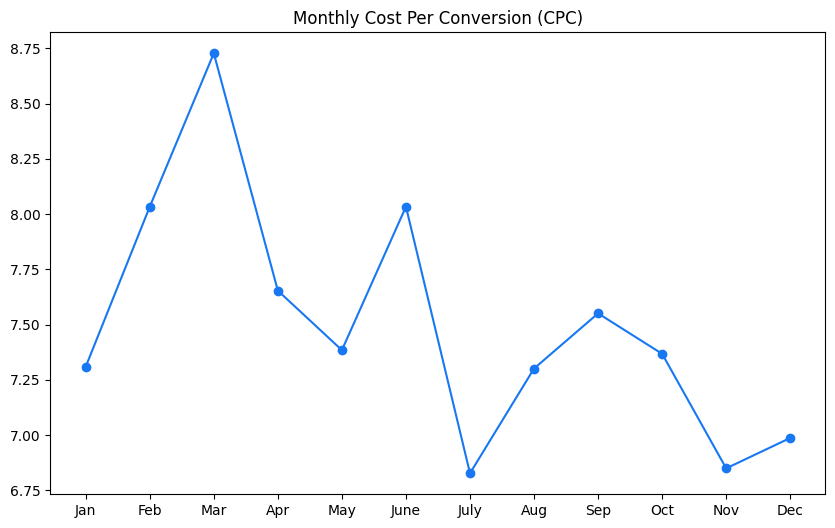

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Monthly Cost Per Conversion (CPC)')
monthly_df = df.groupby('month_idx')[['Facebook Ad Conversions','Cost per Facebook Ad (in $)']].sum()
monthly_df['Cost per Conversion'] = monthly_df['Cost per Facebook Ad (in $)']/monthly_df['Facebook Ad Conversions']
plt.plot(month_names, monthly_df['Cost per Conversion'],'-o', color = '#1877F2')
plt.show()

- Overall Trend: Despite month-to-month volatility, the overall downward trajectory throughout the year confirms a sustained improvement in cost-efficiency and ROI.

- Peak Expenses: Acquisition costs reached their annual peak in March (~8.73), representing the most expensive and highest-friction period for conversions before dropping sharply in April.

- Maximum Efficiency: July and November emerged as the most cost-efficient months of the year, achieving the lowest CPC values (~6.83 and ~6.85, respectively).

- Performance: Correlating this with your previous conversion data shows that the final third of the year (September through December) maintains a consistently low cost-per-conversion baseline, making this the ideal window for maximizing ROI.

#**Relationship between Advertising spend and Conversion rates**
---

What This Test Means
The cointegration test checks if a stable, long-term relationship exists between Facebook Advertising Spend and Facebook Conversions. It determines if they move together reliably over time, rather than just fluctuating randomly.

In [ ]:
score, p_value, _ = coint(df['Cost per Facebook Ad (in $)'], df['Facebook Ad Conversions'])
print('Cointegration test score:', score)
print('P-value:', p_value)
if p_value < 0.05:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")

Cointegration test score: -14.755428385103219
P-value: 2.1337375979061323e-26

p-value is less than significance value, Reject the null hypothesis


**Cointegration Test Score: -14.76**
* Meaning: An exceptionally strong negative test statistic. The further below zero this score is, the more reliably bound together the two metrics are.
* Takeaway: It indicates a powerful, non-random connection between budget and results.

**P-Value: $2.13 \times 10^{-26}$**
* Meaning: The probability that this long-term relationship is a pure statistical coincidence.
* Takeaway: Because it is effectively 0% (far below $\alpha = 0.05$), random chance is entirely ruled out.

* With the p-value near zero, we reject the null
hypothesis, confirming a stable, long-term equilibrium between advertising spend and conversion volume.
* This verified relationship allows for data-driven budget scaling. By prioritizing high-ROI campaigns and adjusting spend based on this predictable trend, we can maximize conversion growth while maintaining cost efficiency.
